# 3.4.2 Data Understanding — Google Trends Malaysia Property Keywords
**File:** `time_series_MY_keywords.csv`

This notebook explores **5 Google Trends search keywords** collected for Malaysia to evaluate their use as a **demand-side sentiment proxy** for the residential property market.

| # | Keyword | Language | Literal Meaning |
|---|---|---|---|
| 1 | `beli rumah` | Malay | buy house |
| 2 | `Property for sale` | English | general property demand |
| 3 | `Terrace house` | English | specific landed property type |
| 4 | `House for sale` | English | general house demand |
| 5 | `Rumah untuk dijual` | Malay | house for sale |

> **Critical note on Google Trends scoring:** All values are **relative (0–100)**, normalised within the chosen time window and geography (Malaysia). A score of 100 = peak search interest for that keyword in the downloaded period — it does **not** represent an absolute search count. This means a score of 50 in 2013 is **not** directly comparable to a score of 50 in 2024.

---
**Research question:** *Is this dataset suitable to act as a sentiment proxy for the Malaysian residential property market?*

---
## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

import os
os.makedirs('images/google_trends', exist_ok=True)

FILE = '../property data/time_series_MY_keywords.csv'
df = pd.read_csv(FILE)
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values('Time').reset_index(drop=True)

KW = ['beli rumah', 'Property for sale', 'Terrace house',
      'House for sale', 'Rumah untuk dijual']
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
LANG = {
    'beli rumah'         : 'Malay: buy house',
    'Property for sale'  : 'English: property for sale',
    'Terrace house'      : 'English: terrace house type',
    'House for sale'     : 'English: house for sale',
    'Rumah untuk dijual' : 'Malay: house for sale'
}

df['Year']  = df['Time'].dt.year
df['Month'] = df['Time'].dt.month
df['comp']  = df[KW].sum(axis=1)
dfp = df[df['Year'] >= 2010].copy().reset_index(drop=True)  # reliable window

print(f'Rows: {len(df)}  |  Cols: {df.shape[1]}')
print(f'Period: {df.Time.min().date()} to {df.Time.max().date()}')
print(f'Reliable subset (2010+): {len(dfp)} rows')
df[['Time'] + KW].head()

Rows: 266  |  Cols: 9
Period: 2004-01-01 to 2026-02-01
Reliable subset (2010+): 194 rows


,Time,beli rumah,Property for sale,Terrace house,House for sale,Rumah untuk dijual
0,2004-01-01,0,0,0,0,0
1,2004-02-01,0,0,0,0,0
2,2004-03-01,0,0,0,0,0
3,2004-04-01,0,0,0,0,0
4,2004-05-01,0,0,0,0,0


---
## 2. Variables — Description of Each Variable

In [2]:
pd.set_option('display.max_colwidth', 95)
var_df = pd.DataFrame({
    'Column'      : ['Time'] + KW,
    'Data Type'   : ['Datetime (Monthly)'] + ['Integer (0–100 relative score)'] * 5,
    'Language'    : ['—', 'Malay', 'English', 'English', 'English', 'Malay'],
    'Period'      : ['Jan 2004 – Feb 2026'] * 6,
    'Description' : [
        'First day of each month (YYYY-MM-DD). Google Trends outputs monthly-aggregated search interest.',
        'beli rumah = buy house. Captures Malay-speaking Malaysians actively searching to purchase residential property.',
        'Broad English-language property demand signal. Covers all property types — landed, high-rise, commercial.',
        'English search for the terrace house property type — the most common landed residential product in Malaysia.',
        'Dominant keyword. Most consistent and strongest signal across the full time series. Englsih-language house buyers.',
        'Rumah untuk dijual = house for sale in Malay. Direct Malay-language equivalent of House for sale.'
    ]
})
display(var_df)

,Column,Data Type,Language,Period,Description
0,Time,Datetime (Monthly),—,Jan 2004 – Feb 2026,First day of each month (YYYY-MM-DD). Google Trends outputs monthly-aggregated search inter...
1,beli rumah,Integer (0–100 relative score),Malay,Jan 2004 – Feb 2026,beli rumah = buy house. Captures Malay-speaking Malaysians actively searching to purchase r...
2,Property for sale,Integer (0–100 relative score),English,Jan 2004 – Feb 2026,"Broad English-language property demand signal. Covers all property types — landed, high-ris..."
3,Terrace house,Integer (0–100 relative score),English,Jan 2004 – Feb 2026,English search for the terrace house property type — the most common landed residential pro...
4,House for sale,Integer (0–100 relative score),English,Jan 2004 – Feb 2026,Dominant keyword. Most consistent and strongest signal across the full time series. Englsih...
5,Rumah untuk dijual,Integer (0–100 relative score),Malay,Jan 2004 – Feb 2026,Rumah untuk dijual = house for sale in Malay. Direct Malay-language equivalent of House for...


---
## 3. Observations — Dataset Overview & Descriptive Statistics
### 3.1 Basic Overview

In [3]:
print('=' * 65)
print('        GOOGLE TRENDS DATASET — OVERVIEW')
print('=' * 65)
print(f'  Monthly observations : {len(df)}')
print(f'  Date range           : {df.Time.min().date()}  to  {df.Time.max().date()}')
print(f'  Keywords             : {len(KW)}  (3 English + 2 Malay)')
print(f'  Missing values (NaN) : {df[KW].isnull().sum().sum()} — none')
print()
print('  Statistics across ALL data (2004–2026):')
for kw in KW:
    d = df[kw]
    print(f'  {kw:<25}: mean={d.mean():.1f}  median={d.median():.0f}  '
          f'max={d.max()}  std={d.std():.1f}')
print()
print('  Statistics — RELIABLE period only (Post-2010):')
for kw in KW:
    d = dfp[kw]
    print(f'  {kw:<25}: mean={d.mean():.1f}  median={d.median():.0f}  '
          f'max={d.max()}  std={d.std():.1f}')
print('=' * 65)

        GOOGLE TRENDS DATASET — OVERVIEW
  Monthly observations : 266
  Date range           : 2004-01-01  to  2026-02-01
  Keywords             : 5  (3 English + 2 Malay)
  Missing values (NaN) : 0 — none

  Statistics across ALL data (2004–2026):
  beli rumah               : mean=13.6  median=14  max=35  std=8.1
  Property for sale        : mean=13.7  median=14  max=34  std=6.5
  Terrace house            : mean=6.9  median=8  max=19  std=3.4
  House for sale           : mean=52.4  median=49  max=100  std=20.6
  Rumah untuk dijual       : mean=19.8  median=19  max=47  std=12.0

  Statistics — RELIABLE period only (Post-2010):
  beli rumah               : mean=17.6  median=17  max=35  std=5.0
  Property for sale        : mean=14.1  median=13  max=29  std=4.5
  Terrace house            : mean=8.1  median=8  max=17  std=1.5
  House for sale           : mean=58.2  median=52  max=100  std=16.2
  Rumah untuk dijual       : mean=22.8  median=21  max=47  std=10.6


### 3.2 Missing Values & Zero-Value Analysis

**What do zeros mean in Google Trends?** A score of 0 does NOT mean zero searches — it means search volume was below the threshold Google needs to normalise and report. In early years (pre-2010), Google's Malaysian coverage was limited and many months fall below this threshold. Zeros here should be treated as **missing / unreliable** data, not true zero interest.

In [4]:
df_pre  = df[df['Year'] < 2010]
df_post = df[df['Year'] >= 2010]

quality = pd.DataFrame({
    'Keyword'          : KW,
    'Total Obs'        : [len(df)] * 5,
    'Total Zeros'      : [(df[k] == 0).sum() for k in KW],
    'Zero %  (all)'    : [(df[k] == 0).mean() * 100 for k in KW],
    'Pre-2010 Zero %'  : [(df_pre[k] == 0).mean() * 100 for k in KW],
    'Post-2010 Zero %' : [(df_post[k] == 0).mean() * 100 for k in KW],
    'First Non-Zero'   : [str(df[df[k] > 0]['Time'].min().date()) for k in KW]
}).round(1)
display(quality)
print()
print('Key insight:')
print('  Pre-2010  → 20–67% of months are zero per keyword (unreliable, exclude from modelling).')
print('  Post-2010 → 0% zeros for ALL keywords (full, reliable coverage).')

,Keyword,Total Obs,Total Zeros,Zero % (all),Pre-2010 Zero %,Post-2010 Zero %,First Non-Zero
0,beli rumah,266,48,18.0,66.7,0.0,2007-07-01
1,Property for sale,266,25,9.4,34.7,0.0,2005-03-01
2,Terrace house,266,42,15.8,58.3,0.0,2006-04-01
3,House for sale,266,15,5.6,20.8,0.0,2005-01-01
4,Rumah untuk dijual,266,32,12.0,44.4,0.0,2005-02-01



Key insight:
  Pre-2010  → 20–67% of months are zero per keyword (unreliable, exclude from modelling).
  Post-2010 → 0% zeros for ALL keywords (full, reliable coverage).


### 3.3 Descriptive Statistics — Post-2010 Reliable Period

In [5]:
desc = dfp[KW + ['comp']].describe().round(2)
desc.index = ['Count','Mean','Std Dev','Min','Q1 (25%)','Median','Q3 (75%)','Max']
desc.columns = KW + ['Composite']
display(desc)
print()
house_pct = dfp['House for sale'].sum() / dfp['comp'].sum() * 100
print(f'House for sale contributes {house_pct:.0f}% of total composite score.')
print('This means the composite is heavily dominated by a single keyword.')

,beli rumah,Property for sale,Terrace house,House for sale,Rumah untuk dijual,Composite
Count,194.00,194.00,194.00,194.00,194.00,194.00
Mean,17.59,14.13,8.09,58.23,22.75,120.79
Std Dev,5.03,4.54,1.49,16.16,10.63,30.99
Min,8.00,7.00,6.00,29.00,7.00,69.00
Q1 (25%),13.00,10.00,7.00,45.25,14.00,96.25
Median,17.00,13.00,8.00,51.50,21.00,116.00
Q3 (75%),21.00,17.00,9.00,72.00,32.00,147.75
Max,35.00,29.00,17.00,100.00,47.00,191.00



House for sale contributes 48% of total composite score.
This means the composite is heavily dominated by a single keyword.


### 3.4 Long-Run Trend Direction (Post-2010)

In [6]:
print('Correlation of each keyword with time index (post-2010):')
print('  r close to -1 = strong downward trend; r close to 0 = flat')
print()
t = np.arange(len(dfp))
for kw in KW:
    arr = dfp[kw].values
    r = np.corrcoef(t, arr)[0, 1]
    direction = 'DECLINING' if r < -0.5 else 'FLAT' if abs(r) < 0.3 else 'RISING'
    print(f'  {kw:<25}: r = {r:+.3f}  → {direction}')
print()


Correlation of each keyword with time index (post-2010):
  r close to -1 = strong downward trend; r close to 0 = flat

  beli rumah               : r = -0.000  → FLAT
  Property for sale        : r = -0.878  → DECLINING
  Terrace house            : r = -0.311  → RISING
  House for sale           : r = -0.877  → DECLINING
  Rumah untuk dijual       : r = -0.901  → DECLINING



---
## 4. Visualisations
### 4.1 All 5 Keywords — Full Time Series (2004–2026)

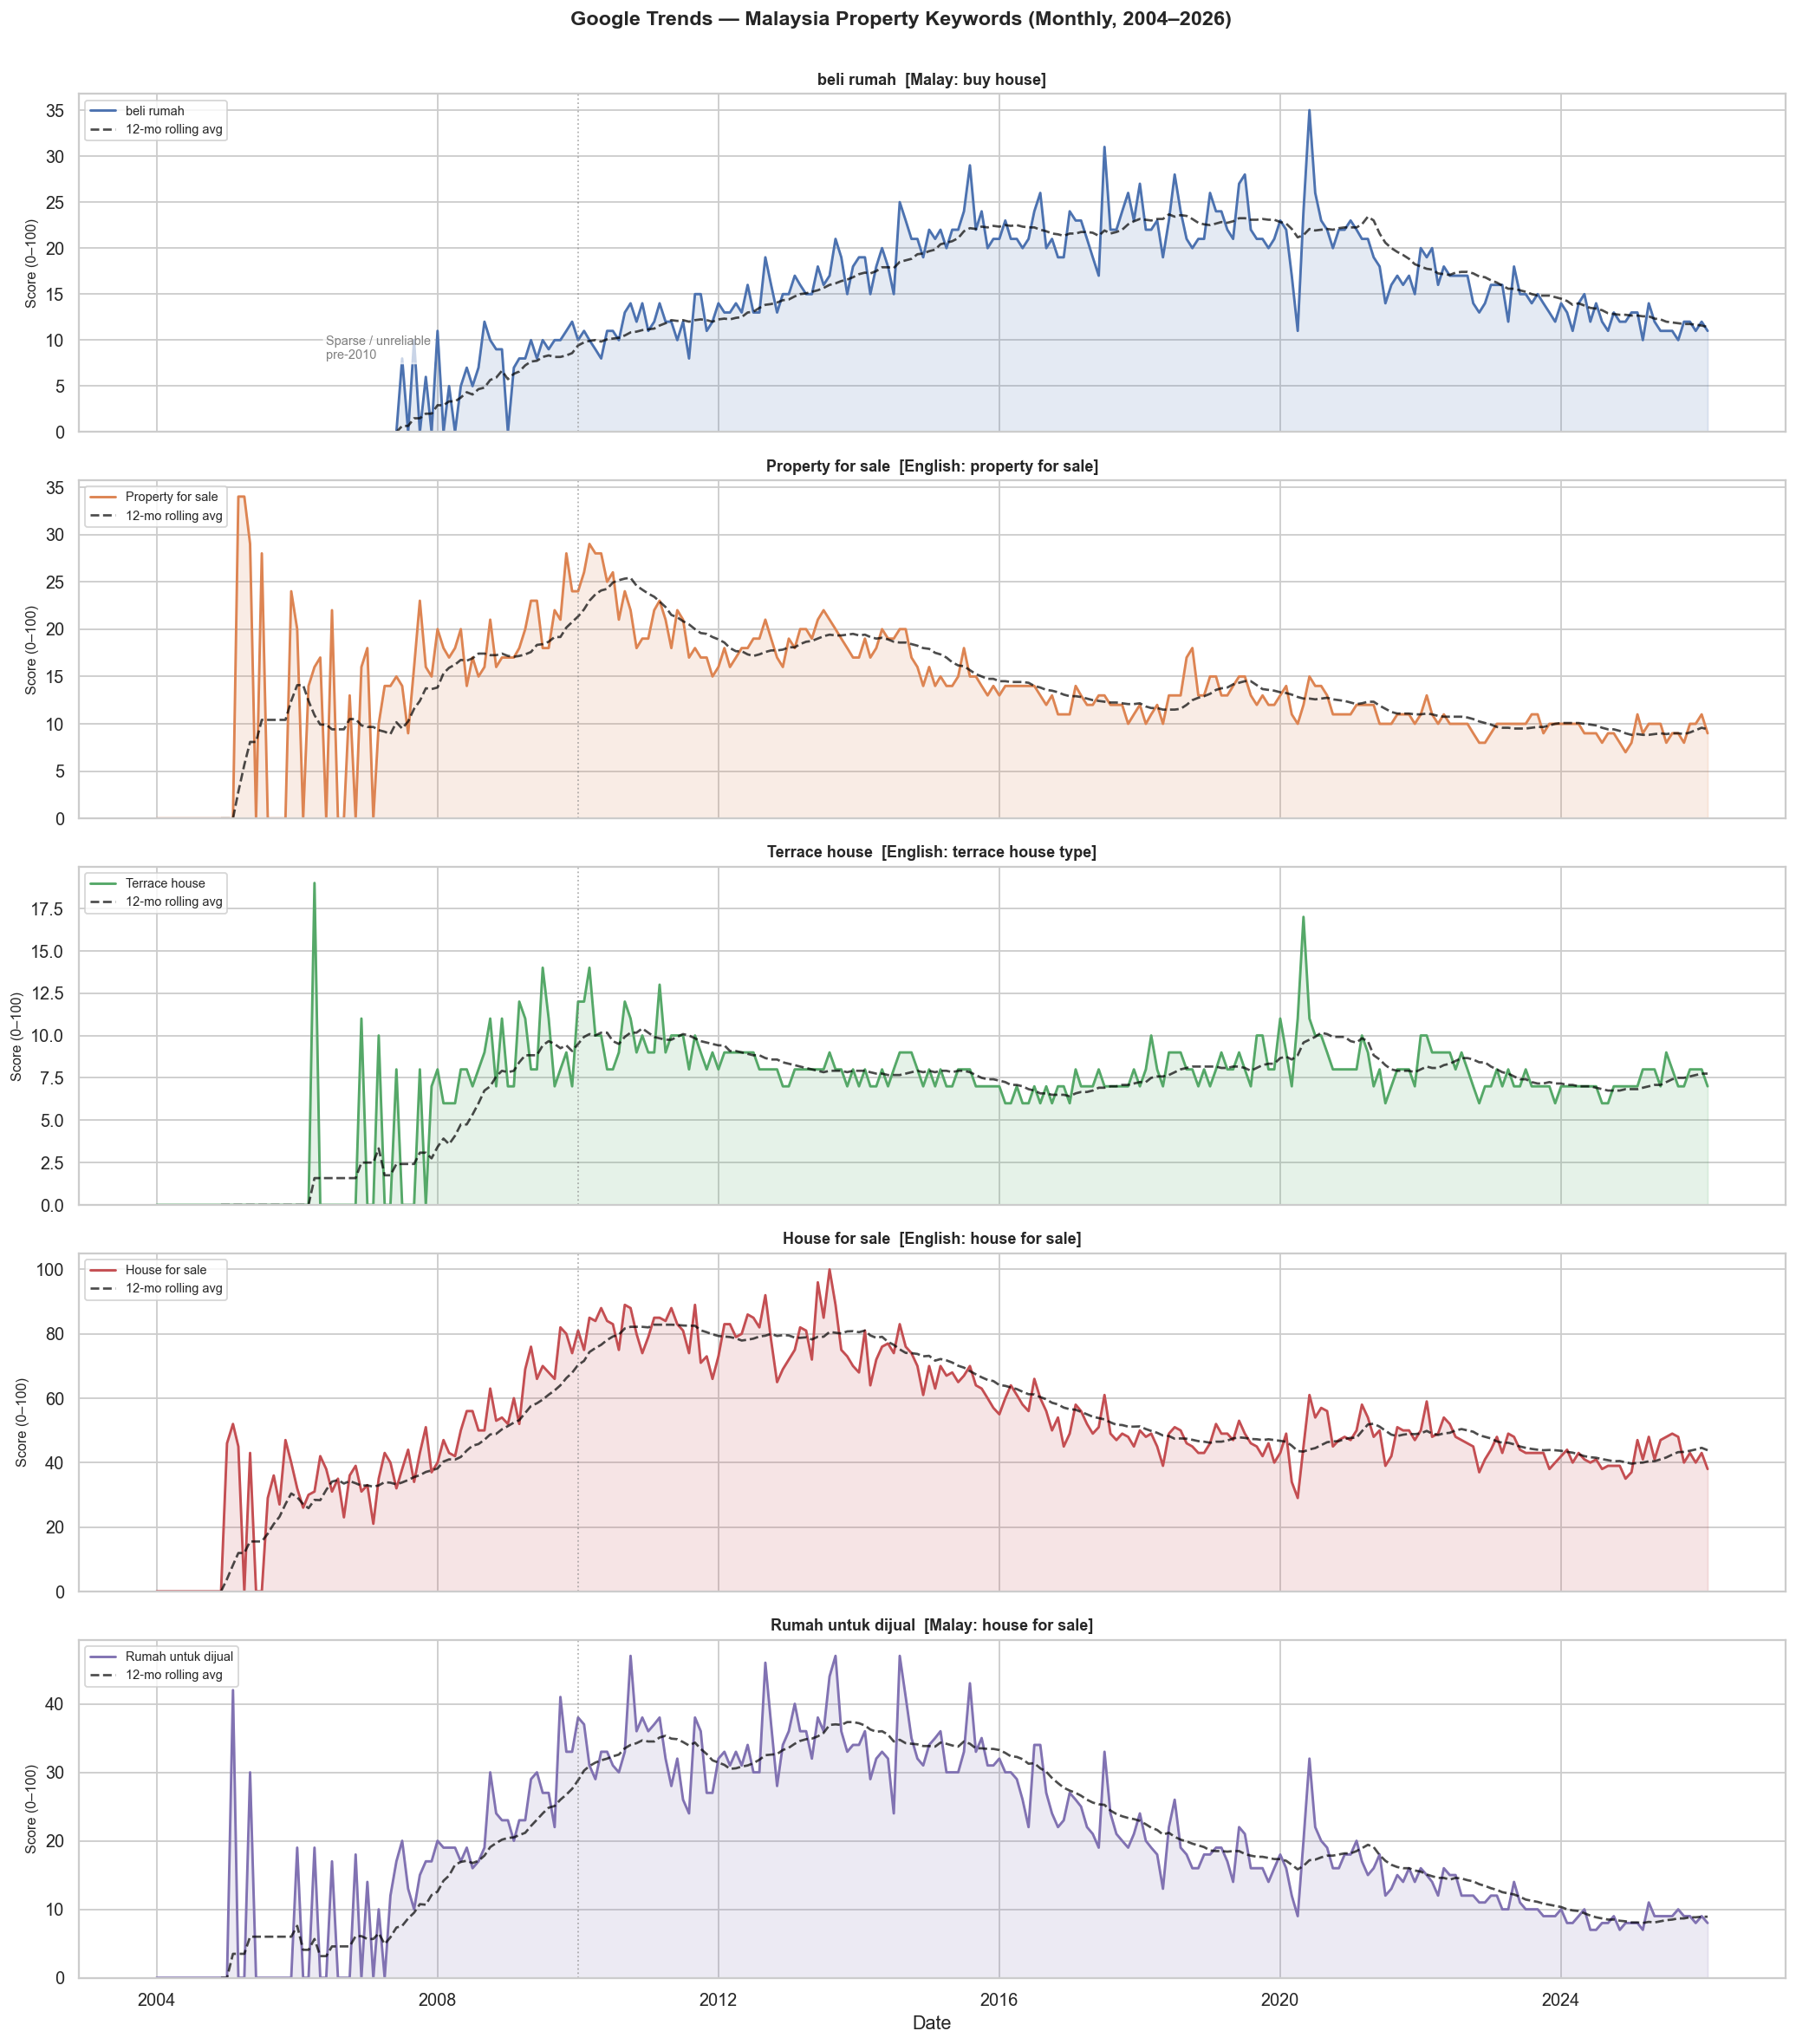

Observations:
  House for sale is the dominant and most consistent keyword across all years.
  All keywords peak around 2012-2014 then show a long structural decline.
  beli rumah shows an anomalous spike in Jun 2020 (COVID-MCO period -- unusual Malay search surge).
  Pre-2010 is visibly erratic and sparse -- not suitable for analysis.


In [7]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
fig.suptitle('Google Trends — Malaysia Property Keywords (Monthly, 2004–2026)',
             fontsize=13, fontweight='bold', y=1.005)

for ax, kw, color in zip(axes, KW, COLORS):
    ax.fill_between(df['Time'], df[kw], alpha=0.15, color=color)
    ax.plot(df['Time'], df[kw], color=color, lw=1.6, label=kw)
    roll = df[kw].rolling(12).mean()
    ax.plot(df['Time'], roll, color='black', lw=1.5, linestyle='--',
            alpha=0.7, label='12-mo rolling avg')
    ax.axvline(pd.Timestamp('2010-01-01'), color='grey', lw=1,
               linestyle=':', alpha=0.6)
    ax.set_ylabel('Score (0–100)', fontsize=9)
    ax.set_ylim(0, None)
    ax.set_title(f'{kw}  [{LANG[kw]}]', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

axes[0].text(pd.Timestamp('2006-06-01'), 8, 'Sparse / unreliable\npre-2010',
             fontsize=8, color='grey',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('images/google_trends/fig_01_all_keywords.png', bbox_inches='tight', dpi=150)
plt.show()
print('Observations:')
print('  House for sale is the dominant and most consistent keyword across all years.')
print('  All keywords peak around 2012-2014 then show a long structural decline.')
print('  beli rumah shows an anomalous spike in Jun 2020 (COVID-MCO period -- unusual Malay search surge).')
print('  Pre-2010 is visibly erratic and sparse -- not suitable for analysis.')

### 4.2 Composite Score Trend (Post-2010)

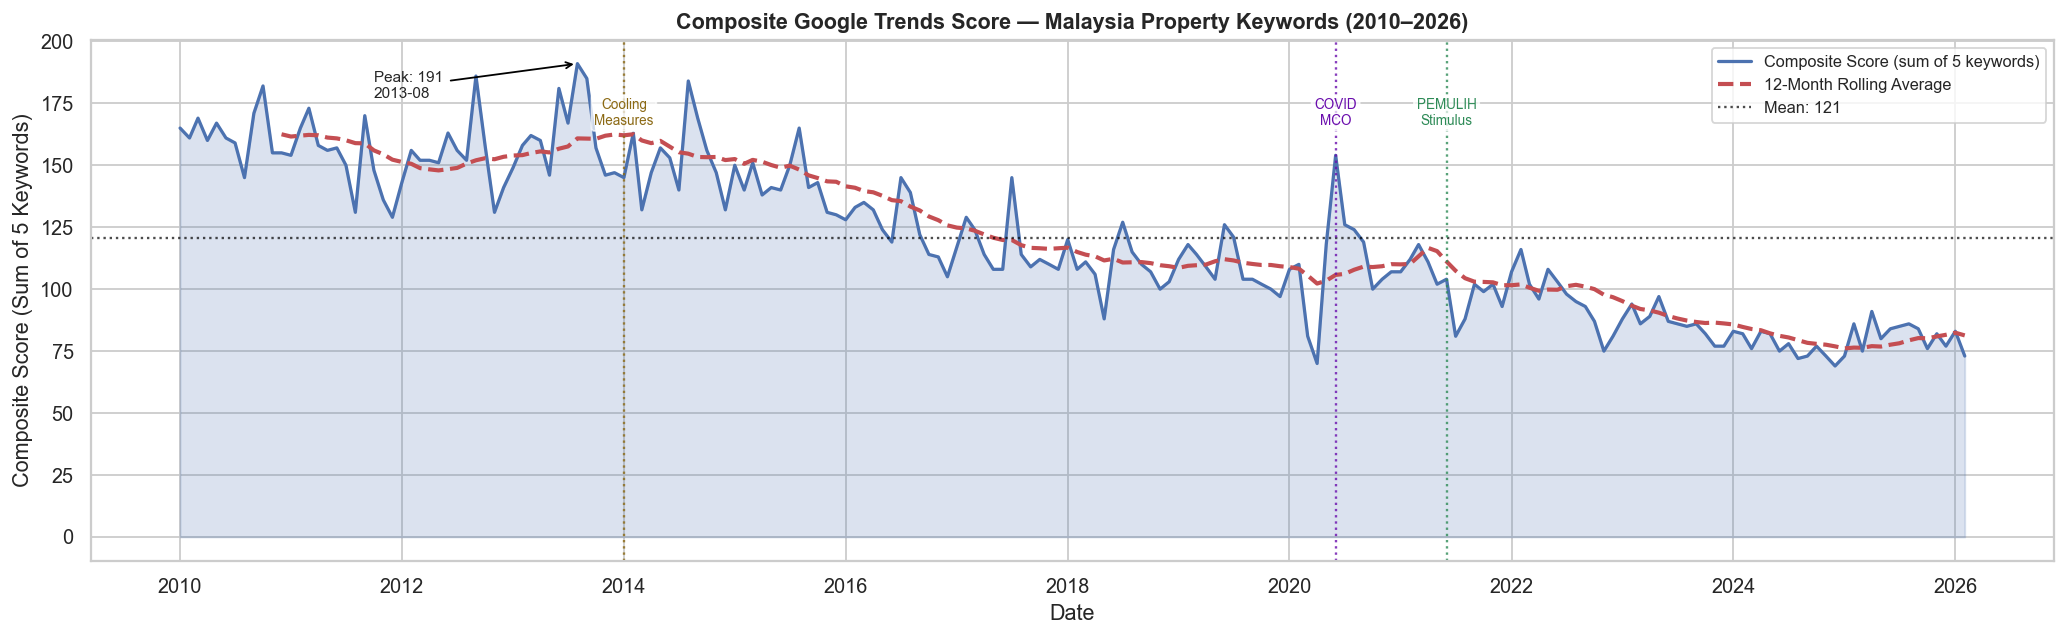

Composite peaked at 191 in 2013-08.
Composite fell from ~162 (2010) to ~77 (2024) -- a 53% structural decline.
This decline reflects migration of property search to dedicated portals, not lower demand.


In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(dfp['Time'], dfp['comp'], alpha=0.2, color='#4C72B0')
ax.plot(dfp['Time'], dfp['comp'], color='#4C72B0', lw=1.8,
        label='Composite Score (sum of 5 keywords)')
roll12 = dfp['comp'].rolling(12).mean()
ax.plot(dfp['Time'], roll12, color='#C44E52', lw=2.3, linestyle='--',
        label='12-Month Rolling Average')
ax.axhline(dfp['comp'].mean(), color='black', lw=1.3, linestyle=':', alpha=0.7,
           label=f"Mean: {dfp['comp'].mean():.0f}")

pk = dfp['comp'].idxmax()
ax.annotate(f"Peak: {int(dfp.loc[pk,'comp'])}\n{str(dfp.loc[pk,'Time'])[:7]}",
            xy=(dfp.loc[pk,'Time'], dfp.loc[pk,'comp']),
            xytext=(dfp.loc[pk,'Time'] - pd.DateOffset(months=22),
                    dfp.loc[pk,'comp'] - 14),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8.5)

for d, lbl, c in [
        (pd.Timestamp('2014-01-01'), 'Cooling\nMeasures', '#8B6914'),
        (pd.Timestamp('2020-06-01'), 'COVID\nMCO',        '#6A0DAD'),
        (pd.Timestamp('2021-06-01'), 'PEMULIH\nStimulus', '#2E8B57')]:
    ax.axvline(d, color=c, lw=1.3, linestyle=':', alpha=0.8)
    ax.text(d, dfp['comp'].max() * 0.87, lbl, fontsize=7.5, color=c,
            ha='center', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_title('Composite Google Trends Score — Malaysia Property Keywords (2010–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Composite Score (Sum of 5 Keywords)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/google_trends/fig_02_composite_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Composite peaked at {int(dfp.loc[pk,'comp'])} in {str(dfp.loc[pk,'Time'])[:7]}.")
print('Composite fell from ~162 (2010) to ~77 (2024) -- a 53% structural decline.')
print('This decline reflects migration of property search to dedicated portals, not lower demand.')

### 4.3 Stacked Area — Relative Contribution by Keyword

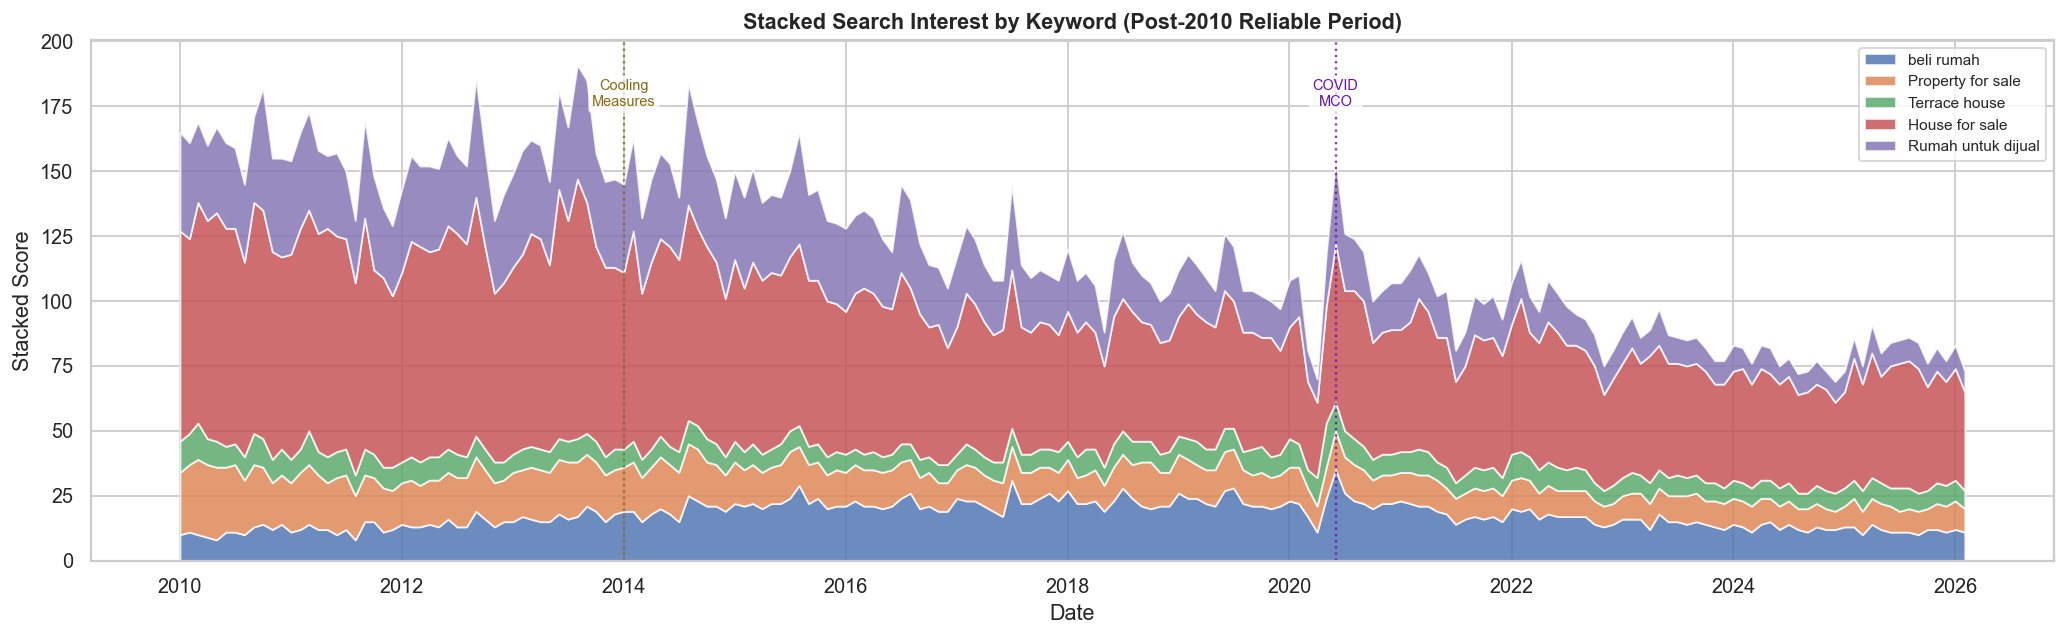

House for sale (red) holds 48% of total stacked score throughout.
English keywords consistently dominate over Malay keywords.


In [9]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.stackplot(dfp['Time'], [dfp[k] for k in KW],
             labels=KW, colors=COLORS, alpha=0.82)
for d, lbl, c in [
        (pd.Timestamp('2014-01-01'), 'Cooling\nMeasures', '#8B6914'),
        (pd.Timestamp('2020-06-01'), 'COVID\nMCO',        '#6A0DAD')]:
    ax.axvline(d, color=c, lw=1.3, linestyle=':', alpha=0.8)
    ax.text(d, 175, lbl, fontsize=8, color=c, ha='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
ax.set_title('Stacked Search Interest by Keyword (Post-2010 Reliable Period)')
ax.set_xlabel('Date')
ax.set_ylabel('Stacked Score')
ax.legend(loc='upper right', fontsize=8.5)
plt.tight_layout()
plt.savefig('images/google_trends/fig_03_stacked_area.png', bbox_inches='tight', dpi=150)
plt.show()
house_pct = dfp['House for sale'].sum() / dfp['comp'].sum() * 100
print(f'House for sale (red) holds {house_pct:.0f}% of total stacked score throughout.')
print('English keywords consistently dominate over Malay keywords.')

### 4.4 Histogram — Distribution of Each Keyword Score (Post-2010)

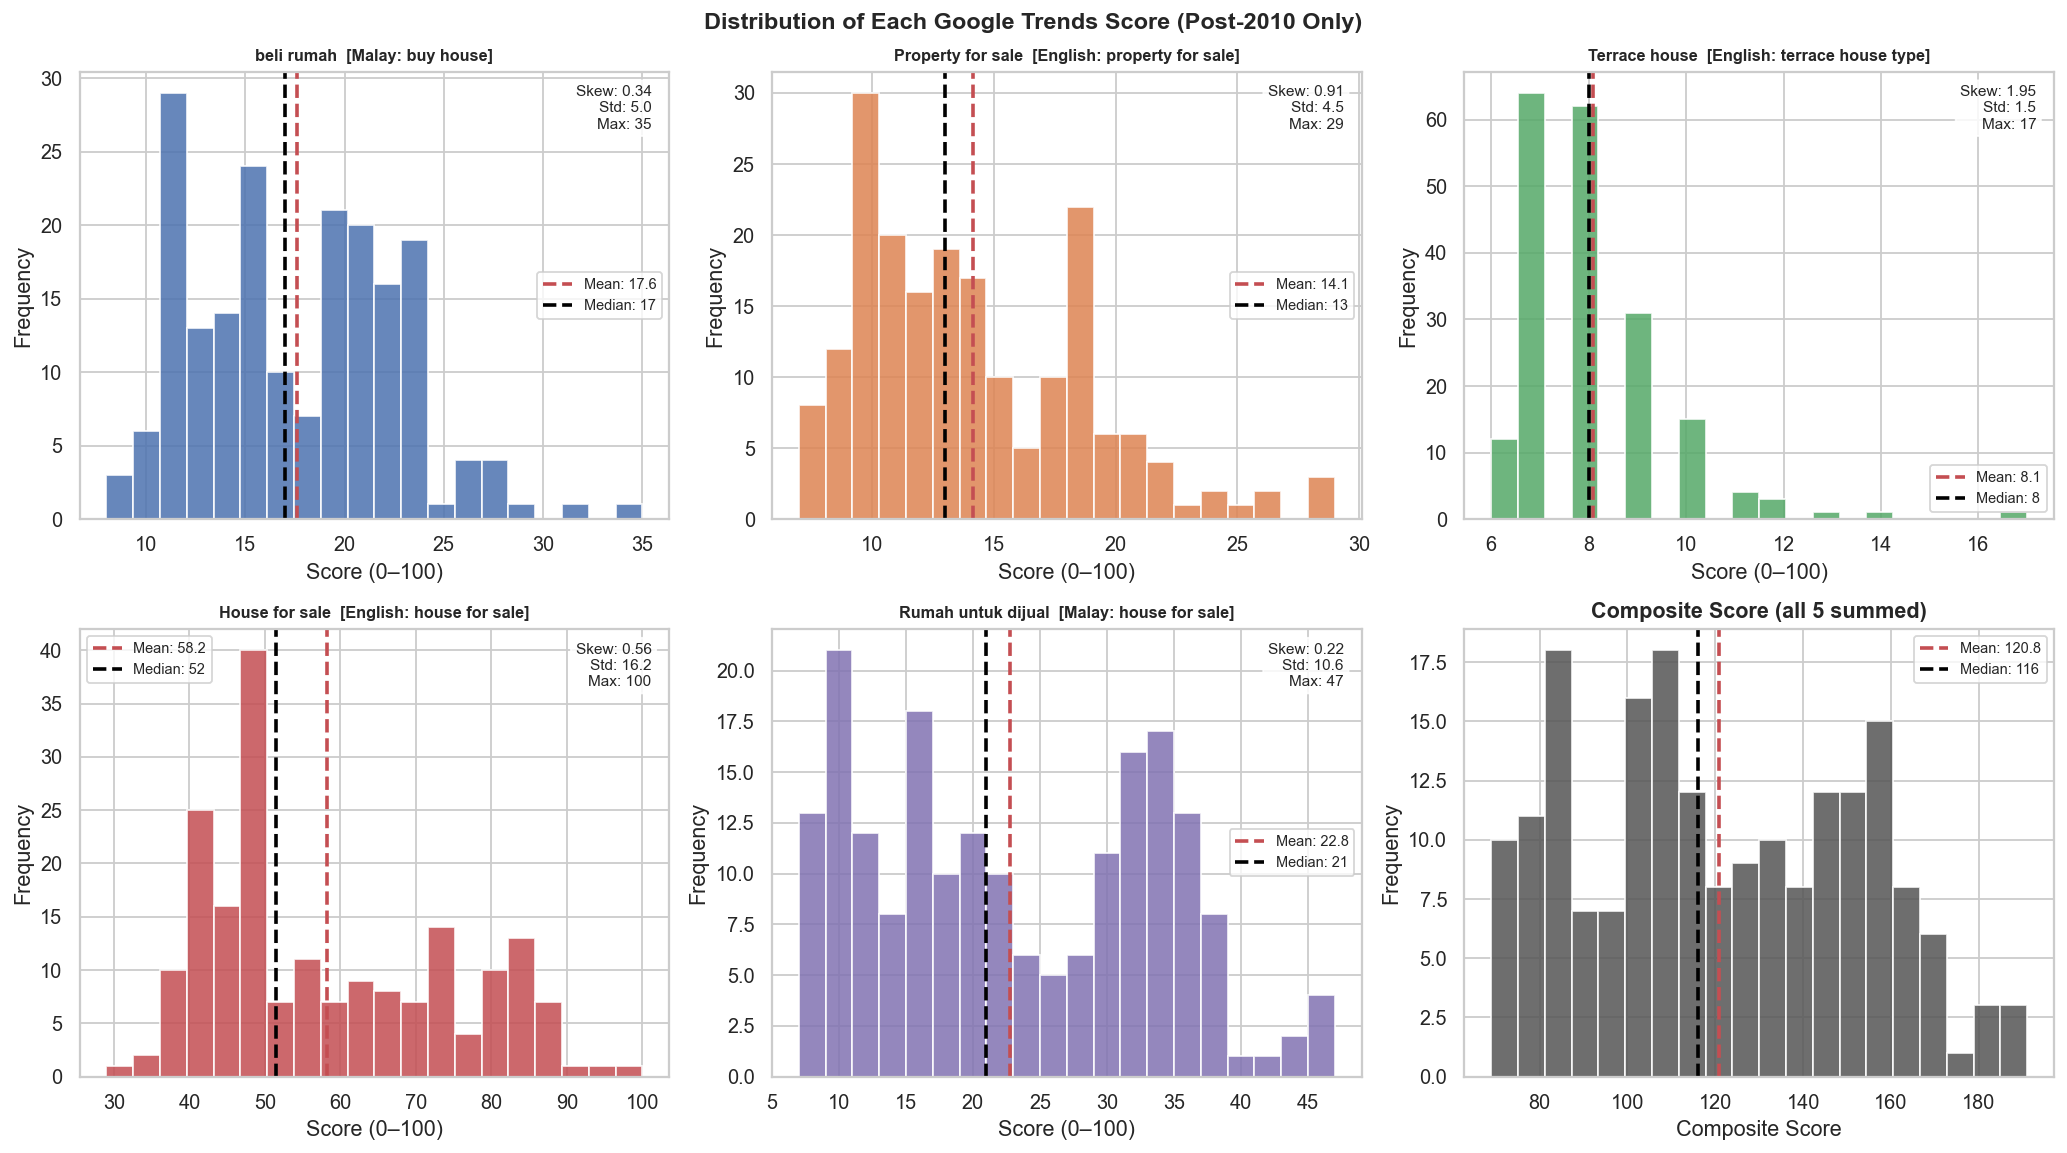

House for sale is right-skewed -- pulled right by 2010-2013 boom values.
Terrace house is narrow and low-variance (max=19 only) -- weak discriminating power.
beli rumah has the flattest distribution -- consistent but trendless.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
flat = axes.flatten()

for i, (kw, color) in enumerate(zip(KW, COLORS)):
    ax = flat[i]
    d = dfp[kw]
    ax.hist(d, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(d.mean(),   color='#C44E52', lw=2, linestyle='--',
               label=f'Mean: {d.mean():.1f}')
    ax.axvline(d.median(), color='black',   lw=2, linestyle='--',
               label=f'Median: {d.median():.0f}')
    skw = float(np.mean(((d - d.mean()) / d.std()) ** 3))
    ax.text(0.97, 0.97,
            f'Skew: {skw:.2f}\nStd: {d.std():.1f}\nMax: {d.max()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.set_title(f'{kw}  [{LANG[kw]}]', fontsize=9)
    ax.set_xlabel('Score (0–100)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

# Composite in last panel
ax = flat[5]
d = dfp['comp']
ax.hist(d, bins=20, color='#555', edgecolor='white', alpha=0.85)
ax.axvline(d.mean(),   color='#C44E52', lw=2, linestyle='--',
           label=f'Mean: {d.mean():.1f}')
ax.axvline(d.median(), color='black',   lw=2, linestyle='--',
           label=f'Median: {d.median():.0f}')
ax.set_title('Composite Score (all 5 summed)')
ax.set_xlabel('Composite Score')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

fig.suptitle('Distribution of Each Google Trends Score (Post-2010 Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/google_trends/fig_04_histogram.png', bbox_inches='tight', dpi=150)
plt.show()
print('House for sale is right-skewed -- pulled right by 2010-2013 boom values.')
print('Terrace house is narrow and low-variance (max=19 only) -- weak discriminating power.')
print('beli rumah has the flattest distribution -- consistent but trendless.')

### 4.5 Correlation Matrix (Post-2010)

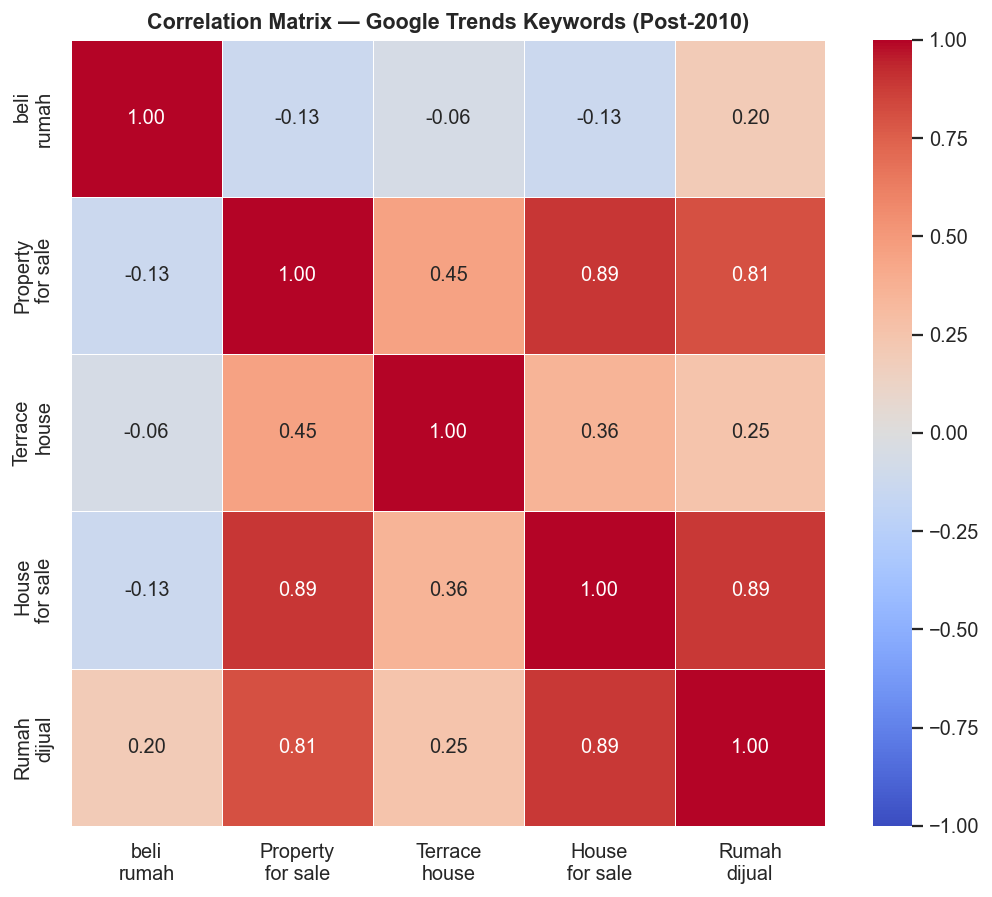

Key correlations:
  House for sale            <-> Rumah untuk dijual       : r = +0.887  (same intent, bilingual validation)
  Property for sale         <-> House for sale           : r = +0.892  (overlapping English buyer intent)
  Property for sale         <-> Rumah untuk dijual       : r = +0.807  (cross-language, overlapping intent)
  beli rumah                <-> Property for sale        : r = -0.130  (different demographics, weaker link)
  beli rumah                <-> House for sale           : r = -0.131  (beli rumah is near-flat, others declining)


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
corr = dfp[KW].corr()
short = ['beli\nrumah', 'Property\nfor sale', 'Terrace\nhouse',
         'House\nfor sale', 'Rumah\ndijual']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 11},
            xticklabels=short, yticklabels=short)
ax.set_title('Correlation Matrix — Google Trends Keywords (Post-2010)')
plt.tight_layout()
plt.savefig('images/google_trends/fig_05_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('Key correlations:')
pairs = [
    ('House for sale', 'Rumah untuk dijual', 'same intent, bilingual validation'),
    ('Property for sale', 'House for sale',  'overlapping English buyer intent'),
    ('Property for sale', 'Rumah untuk dijual', 'cross-language, overlapping intent'),
    ('beli rumah', 'Property for sale', 'different demographics, weaker link'),
    ('beli rumah', 'House for sale',    'beli rumah is near-flat, others declining'),
]
for a, b, note in pairs:
    print(f'  {a:<25} <-> {b:<25}: r = {corr.loc[a,b]:+.3f}  ({note})')

### 4.6 Seasonal Pattern — Monthly Averages

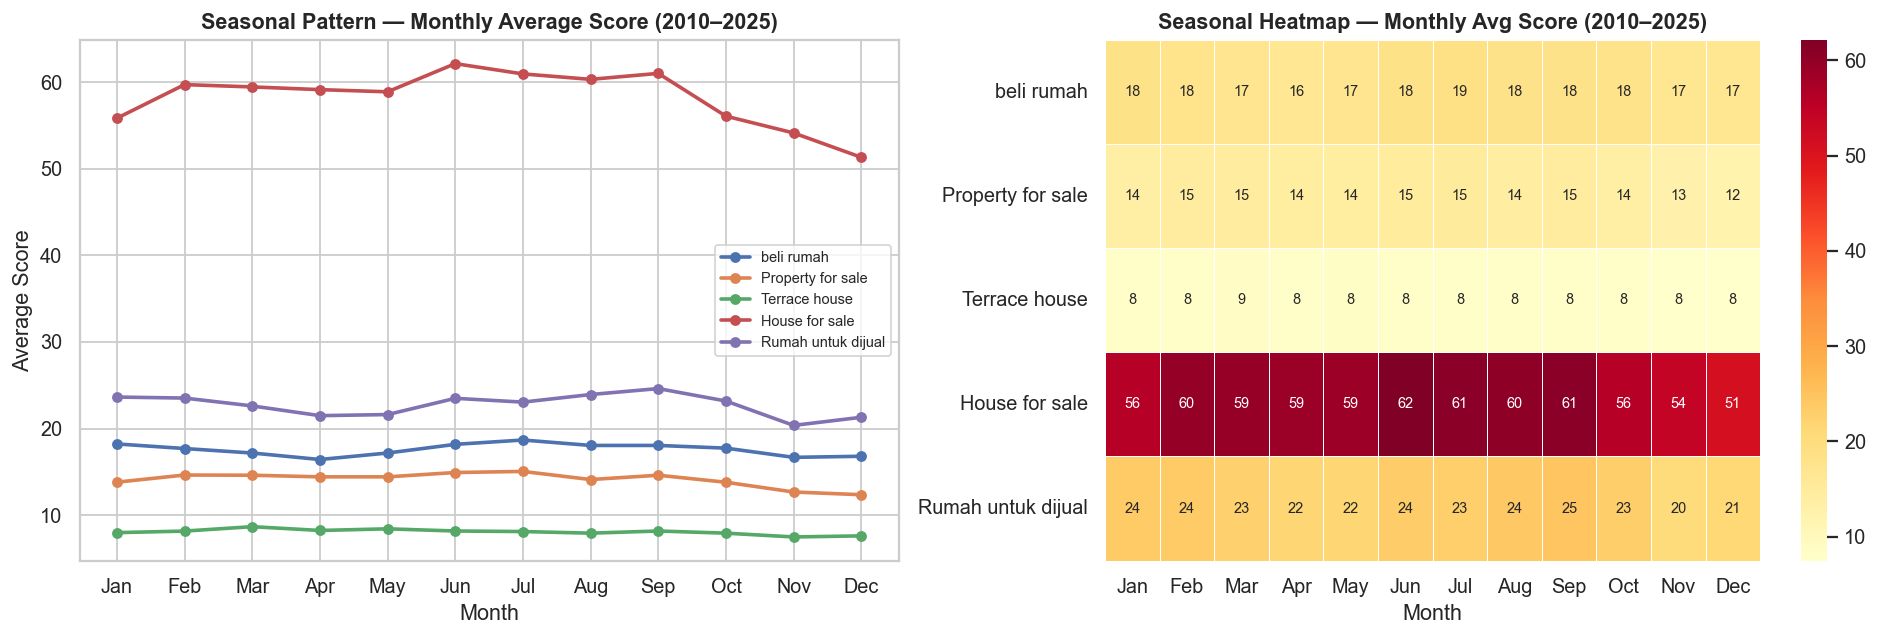

Seasonality is WEAK overall -- scores are relatively flat month-to-month.
Slight mid-year uplift (Jun-Sep) in House for sale mirrors the property
market buying cycle (after school year planning, pre-year-end).
Nov-Dec is slightly weaker -- festive season + year-end slowdown.


In [12]:
sea = dfp.groupby('Month')[KW].mean()
mlabels = ['Jan','Feb','Mar','Apr','May','Jun',
           'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for kw, color in zip(KW, COLORS):
    axes[0].plot(range(1, 13), sea[kw], marker='o', color=color,
                 lw=2, markersize=5, label=kw)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mlabels)
axes[0].set_title('Seasonal Pattern — Monthly Average Score (2010–2025)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Score')
axes[0].legend(fontsize=8)

sns.heatmap(sea[KW].T, ax=axes[1], cmap='YlOrRd',
            xticklabels=mlabels, yticklabels=KW,
            annot=True, fmt='.0f', annot_kws={'size': 8}, linewidths=0.3)
axes[1].set_title('Seasonal Heatmap — Monthly Avg Score (2010–2025)')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.savefig('images/google_trends/fig_06_seasonal.png', bbox_inches='tight', dpi=150)
plt.show()

print('Seasonality is WEAK overall -- scores are relatively flat month-to-month.')
print('Slight mid-year uplift (Jun-Sep) in House for sale mirrors the property')
print('market buying cycle (after school year planning, pre-year-end).')
print('Nov-Dec is slightly weaker -- festive season + year-end slowdown.')

### 4.7 Annual Average Trends

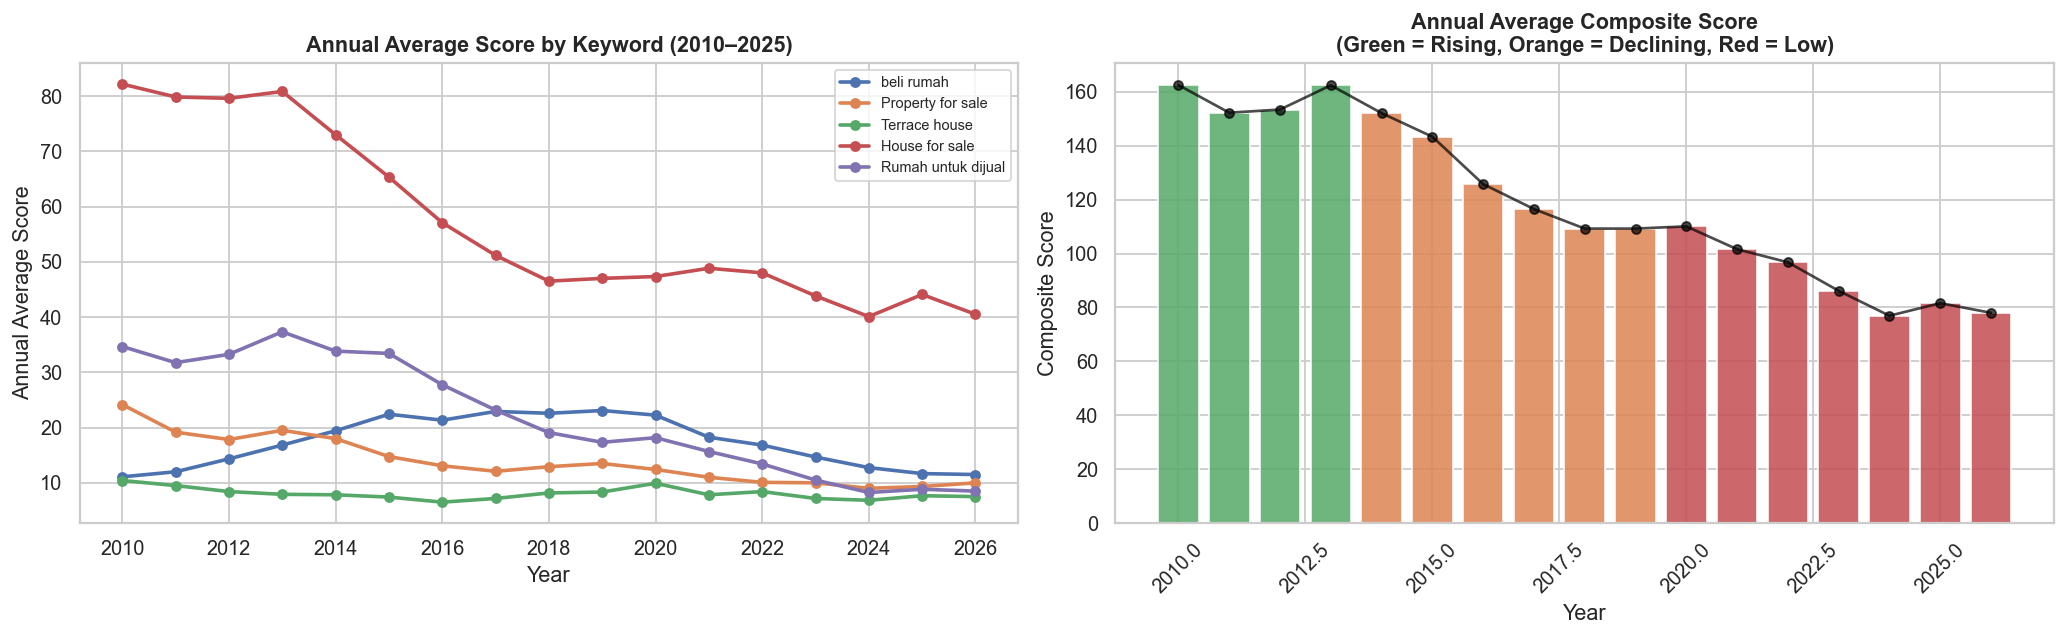

Change in annual average score per keyword (2010 vs 2024):
  beli rumah               : 11.1 --> 12.8  (+15%)
  Property for sale        : 24.2 --> 9.0  (-63%)
  Terrace house            : 10.4 --> 6.8  (-34%)
  House for sale           : 82.2 --> 40.1  (-51%)
  Rumah untuk dijual       : 34.7 --> 8.2  (-76%)


In [13]:
yr = dfp.groupby('Year')[KW + ['comp']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for kw, color in zip(KW, COLORS):
    axes[0].plot(yr.index, yr[kw], marker='o', color=color,
                 lw=2, markersize=5, label=kw)
axes[0].set_title('Annual Average Score by Keyword (2010–2025)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Annual Average Score')
axes[0].legend(fontsize=8)

bar_c = ['#55A868' if y <= 2013
         else '#DD8452' if y <= 2019
         else '#C44E52'
         for y in yr.index]
axes[1].bar(yr.index, yr['comp'], color=bar_c, edgecolor='white', alpha=0.85)
axes[1].plot(yr.index, yr['comp'], 'o-', color='black', lw=1.5, markersize=5, alpha=0.7)
axes[1].set_title('Annual Average Composite Score\n'
                  '(Green = Rising, Orange = Declining, Red = Low)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Composite Score')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/google_trends/fig_07_annual_average.png', bbox_inches='tight', dpi=150)
plt.show()

print('Change in annual average score per keyword (2010 vs 2024):')
for kw in KW:
    a, b = yr.loc[2010, kw], yr.loc[2024, kw]
    print(f'  {kw:<25}: {a:.1f} --> {b:.1f}  ({(b-a)/a*100:+.0f}%)')

### 4.8 English vs Malay Keyword Breakdown

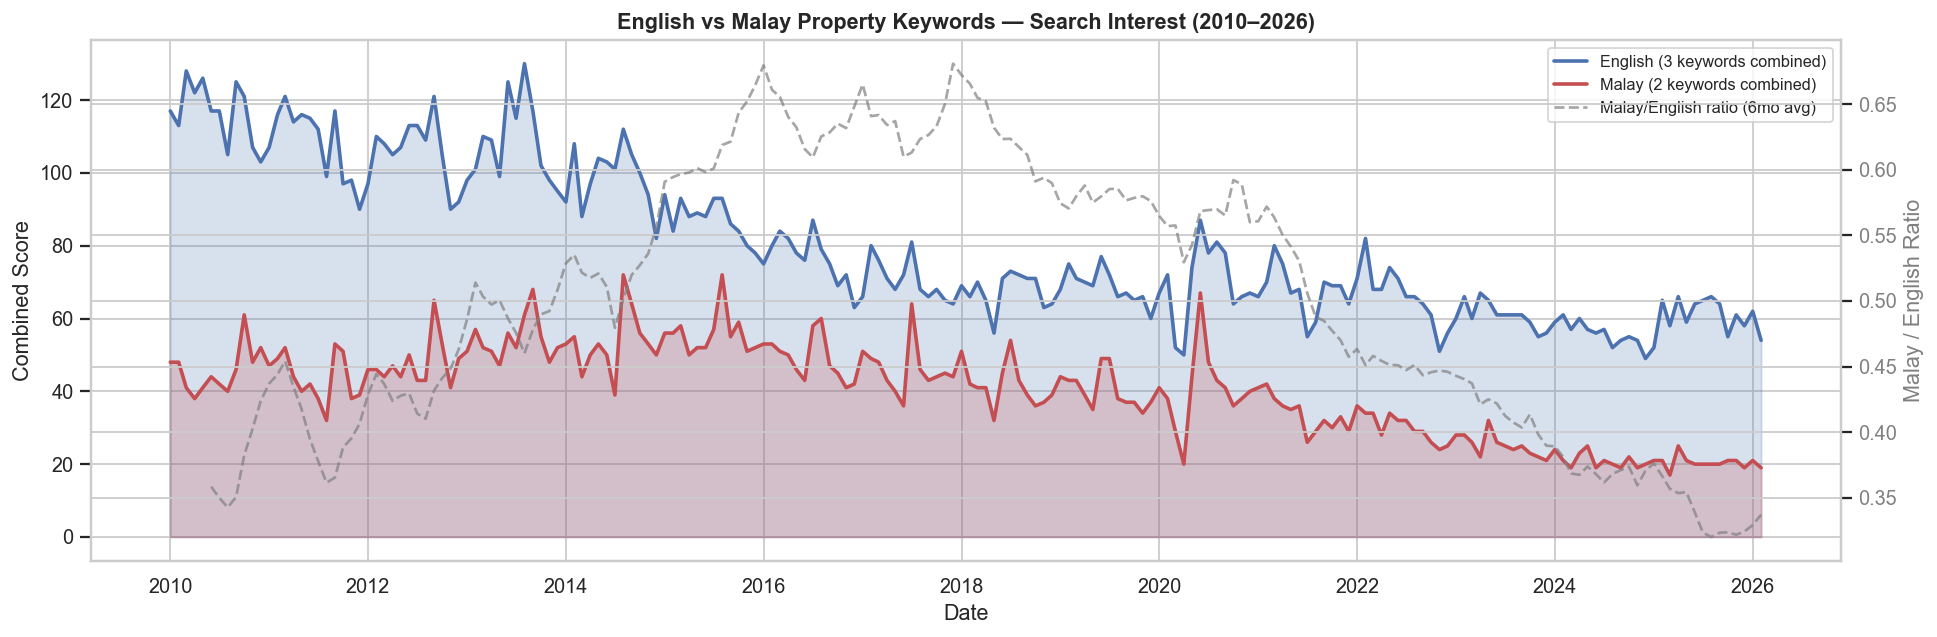

English keywords: 67% of total composite score.
Malay/English ratio is slowly rising -- Malay-language search growing relatively.
Suggests broadening digital adoption among Malay-speaking property buyers.


In [14]:
dfp2 = dfp.copy()
dfp2['English'] = (dfp2['Property for sale'] +
                   dfp2['Terrace house'] +
                   dfp2['House for sale'])
dfp2['Malay']   = dfp2['beli rumah'] + dfp2['Rumah untuk dijual']

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()
ax1.fill_between(dfp2['Time'], dfp2['English'], alpha=0.22, color='#4C72B0')
ax1.fill_between(dfp2['Time'], dfp2['Malay'],   alpha=0.22, color='#C44E52')
l1, = ax1.plot(dfp2['Time'], dfp2['English'], color='#4C72B0', lw=2,
               label='English (3 keywords combined)')
l2, = ax1.plot(dfp2['Time'], dfp2['Malay'],   color='#C44E52', lw=2,
               label='Malay (2 keywords combined)')
ratio = dfp2['Malay'] / (dfp2['English'] + 1)
l3, = ax2.plot(dfp2['Time'], ratio.rolling(6).mean(),
               color='grey', lw=1.5, linestyle='--', alpha=0.7,
               label='Malay/English ratio (6mo avg)')
ax1.set_title('English vs Malay Property Keywords — Search Interest (2010–2026)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Combined Score')
ax2.set_ylabel('Malay / English Ratio', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')
ax1.legend(handles=[l1, l2, l3], fontsize=9)
plt.tight_layout()
plt.savefig('images/google_trends/fig_08_english_malay.png', bbox_inches='tight', dpi=150)
plt.show()

eng_pct = dfp2['English'].sum() / dfp2['comp'].sum() * 100
print(f'English keywords: {eng_pct:.0f}% of total composite score.')
print('Malay/English ratio is slowly rising -- Malay-language search growing relatively.')
print('Suggests broadening digital adoption among Malay-speaking property buyers.')

### 4.9 Data Quality — Pre vs Post 2010

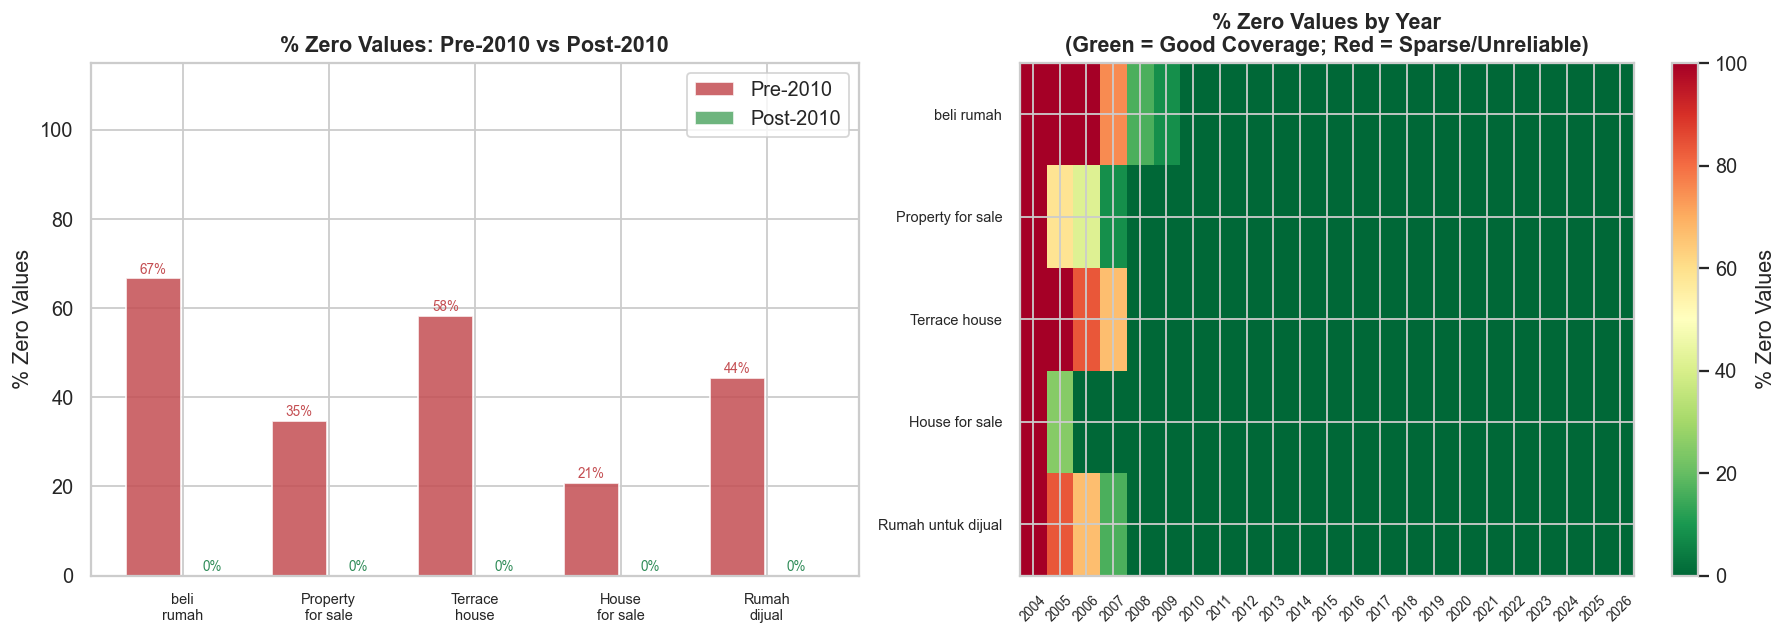

Recommendation: use 2010 onwards as the analytical window.


In [15]:
df_yrz = (df.groupby('Year')[KW]
          .apply(lambda x: (x == 0).mean() * 100)
          .reset_index())
df_yrz.columns = ['Year'] + KW
df_pre  = df[df['Year'] < 2010]
df_post = df[df['Year'] >= 2010]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

zp  = [(df_pre[k]  == 0).mean() * 100 for k in KW]
zpo = [(df_post[k] == 0).mean() * 100 for k in KW]
x = np.arange(len(KW))
sk = ['beli\nrumah','Property\nfor sale','Terrace\nhouse',
      'House\nfor sale','Rumah\ndijual']
axes[0].bar(x-0.2, zp,  0.38, color='#C44E52', label='Pre-2010',
            edgecolor='white', alpha=0.85)
axes[0].bar(x+0.2, zpo, 0.38, color='#55A868', label='Post-2010',
            edgecolor='white', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sk, fontsize=8)
axes[0].set_title('% Zero Values: Pre-2010 vs Post-2010')
axes[0].set_ylabel('% Zero Values')
axes[0].legend()
axes[0].set_ylim(0, 115)
for i, (a, b) in enumerate(zip(zp, zpo)):
    axes[0].text(i-0.2, a+1, f'{a:.0f}%', ha='center', fontsize=7.5, color='#C44E52')
    axes[0].text(i+0.2, b+1, f'{b:.0f}%', ha='center', fontsize=7.5, color='#2E8B57')

im = axes[1].imshow(df_yrz[KW].T.values, aspect='auto',
                    cmap='RdYlGn_r', vmin=0, vmax=100)
axes[1].set_yticks(range(len(KW)))
axes[1].set_yticklabels(KW, fontsize=8)
axes[1].set_xticks(range(len(df_yrz)))
axes[1].set_xticklabels(df_yrz['Year'].astype(int), rotation=45, fontsize=7.5)
axes[1].set_title('% Zero Values by Year\n(Green = Good Coverage; Red = Sparse/Unreliable)')
plt.colorbar(im, ax=axes[1], label='% Zero Values')
plt.tight_layout()
plt.savefig('images/google_trends/fig_09_data_quality.png', bbox_inches='tight', dpi=150)
plt.show()
print('Recommendation: use 2010 onwards as the analytical window.')

### 4.10 Suitability Assessment Dashboard

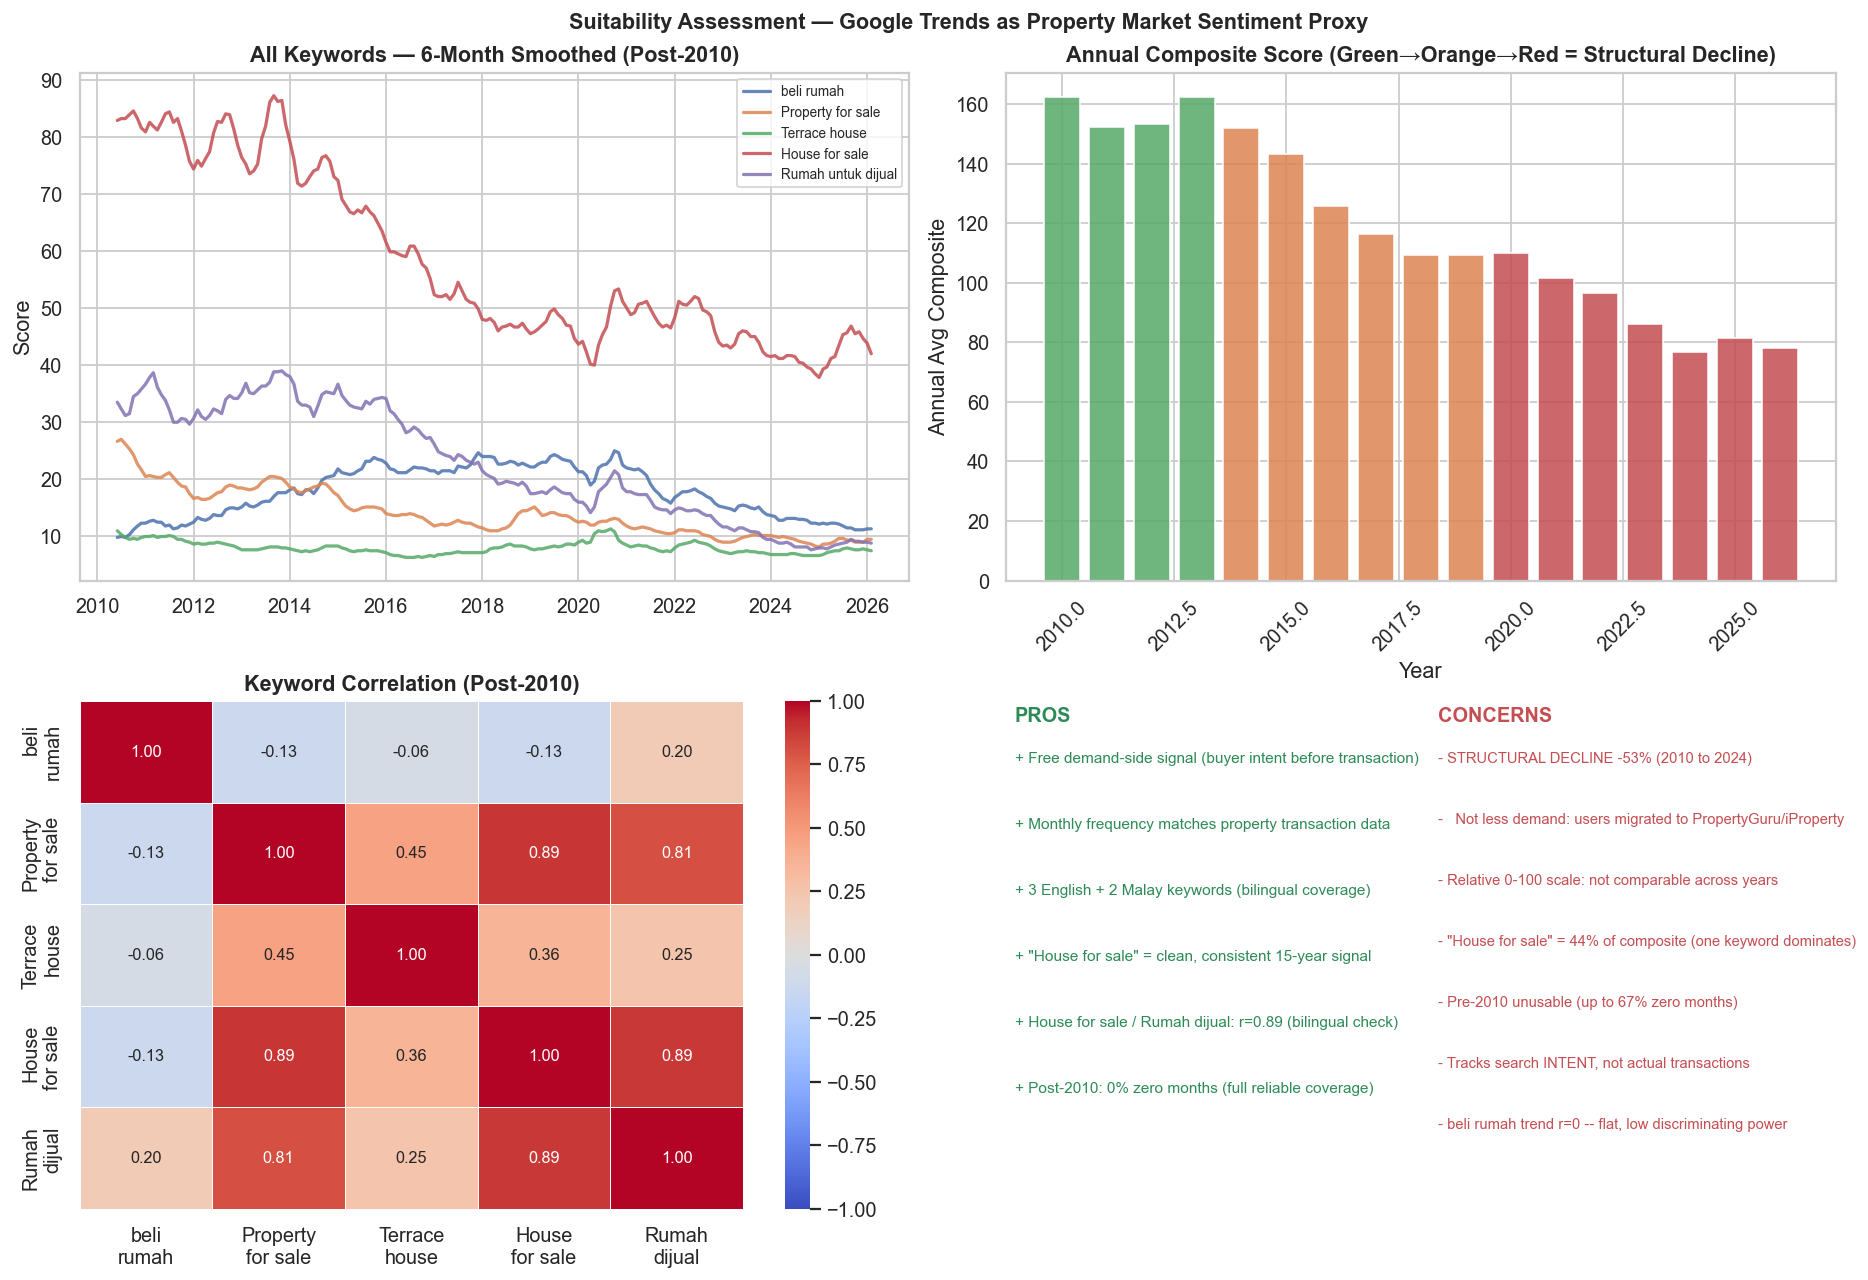

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Suitability Assessment — Google Trends as Property Market Sentiment Proxy',
             fontsize=12, fontweight='bold')

# Panel 1: smoothed all keywords
ax = axes[0, 0]
for kw, color in zip(KW, COLORS):
    ax.plot(dfp['Time'], dfp[kw].rolling(6).mean(),
            color=color, lw=1.8, alpha=0.85, label=kw)
ax.set_title('All Keywords — 6-Month Smoothed (Post-2010)')
ax.set_ylabel('Score')
ax.legend(fontsize=7.5)

# Panel 2: annual composite decline
ax = axes[0, 1]
yr2 = dfp.groupby('Year')['comp'].mean()
bar_c2 = ['#55A868' if y<=2013 else '#DD8452' if y<=2019 else '#C44E52'
          for y in yr2.index]
ax.bar(yr2.index, yr2, color=bar_c2, edgecolor='white', alpha=0.85)
ax.set_title('Annual Composite Score (Green→Orange→Red = Structural Decline)')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Avg Composite')
ax.tick_params(axis='x', rotation=45)

# Panel 3: correlation heatmap
ax = axes[1, 0]
sk = ['beli\nrumah','Property\nfor sale','Terrace\nhouse',
      'House\nfor sale','Rumah\ndijual']
sns.heatmap(dfp[KW].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9},
            xticklabels=sk, yticklabels=sk, linewidths=0.4)
ax.set_title('Keyword Correlation (Post-2010)')

# Panel 4: pros/cons text
ax = axes[1, 1]
ax.axis('off')
pros = [
    'Free demand-side signal (buyer intent before transaction)',
    'Monthly frequency matches property transaction data',
    '3 English + 2 Malay keywords (bilingual coverage)',
    '"House for sale" = clean, consistent 15-year signal',
    'House for sale / Rumah dijual: r=0.89 (bilingual check)',
    'Post-2010: 0% zero months (full reliable coverage)',
]
cons = [
    'STRUCTURAL DECLINE -53% (2010 to 2024)',
    '  Not less demand: users migrated to PropertyGuru/iProperty',
    'Relative 0-100 scale: not comparable across years',
    '"House for sale" = 44% of composite (one keyword dominates)',
    'Pre-2010 unusable (up to 67% zero months)',
    'Tracks search INTENT, not actual transactions',
    'beli rumah trend r=0 -- flat, low discriminating power',
]
ax.text(0.01, 0.99, 'PROS', fontsize=11, fontweight='bold', color='#2E8B57',
        transform=ax.transAxes, va='top')
for i, p in enumerate(pros):
    ax.text(0.01, 0.90 - i*0.13, f'+ {p}', fontsize=8.5, color='#2E8B57',
            transform=ax.transAxes, va='top')
ax.text(0.52, 0.99, 'CONCERNS', fontsize=11, fontweight='bold', color='#C44E52',
        transform=ax.transAxes, va='top')
for i, c in enumerate(cons):
    ax.text(0.52, 0.90 - i*0.12, f'- {c}', fontsize=8.2, color='#C44E52',
            transform=ax.transAxes, va='top')

plt.tight_layout()
plt.savefig('images/google_trends/fig_10_suitability.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Suitability Assessment

### 5.1 What This Data Captures
Google Trends scores measure **relative search interest** by Malaysians for property-related terms. Elevated search volume for terms like *House for sale* signals heightened buyer curiosity — demand-side intent that may **lead** actual transaction volumes by weeks to months.

### 5.2 Strengths

| # | Strength | Detail |
|---|---|---|
| 1 | Free demand-side signal | Captures buyer intent before a transaction occurs |
| 2 | Bilingual coverage | 3 English + 2 Malay keywords reach both buyer demographics |
| 3 | Monthly frequency | Aligns directly with property transaction reporting |
| 4 | Long usable window | 15+ years of reliable data post-2010 |
| 5 | Internal consistency | House for sale vs Rumah untuk dijual r = 0.89 — same intent, both languages |
| 6 | Full post-2010 coverage | 0% zero months after 2010 for all keywords |

### 5.3 Concerns & Limitations

| # | Concern | Why It Matters |
|---|---|---|
| 1 | **Structural downward trend** | Composite fell 53% from 2010 to 2024. This is NOT falling demand — it reflects migration of property search to dedicated portals (PropertyGuru, iProperty, Mudah.my). This structural shift will confound any model that treats absolute levels as meaningful. |
| 2 | **Relative scale (0–100)** | Score of 50 in 2013 ≠ Score of 50 in 2024. Absolute values are not inter-temporally comparable. |
| 3 | **Single keyword dominance** | House for sale = ~44% of composite. The composite is essentially a proxy for one keyword, not a diverse signal. |
| 4 | **Pre-2010 unusable** | Up to 67% zero months before 2010 — cannot be used for analysis or modelling. |
| 5 | **Search ≠ Transaction** | High search may be window-shopping or curiosity, not genuine purchase intent. |
| 6 | **beli rumah is flat** | Trend correlation r ≈ 0 — this keyword does not move with the market cycle, limiting its predictive value. |

### 5.4 Verdict

> **Conditionally suitable — requires pre-processing before use in any model.**

Before using this data as a sentiment feature:

1. **Use post-2010 data only** — drop all rows before January 2010.
2. **Detrend the series** — use YoY % change (e.g. `score_t / score_{t-12} - 1`) rather than absolute scores to remove the structural platform-migration decline.
3. **Favour `House for sale` as the primary signal** — it is the cleanest and most consistent keyword. The composite may add noise rather than diversification.
4. **Run a lag analysis** — test whether search volume at time *t* leads transaction volumes at *t+1*, *t+2*, *t+3* before including as a model predictor.
5. **Do not interpret absolute level** — only directional changes and relative movements carry meaning.

---
## 6. Key Findings Summary

| # | Finding |
|---|---|
| 1 | Dataset: 266 monthly observations × 5 keywords (Jan 2004 – Feb 2026) |
| 2 | Pre-2010 data is **unreliable** — 20–67% zero months per keyword; usable window starts Jan 2010 |
| 3 | Post-2010: **0% zero months** for all keywords — full coverage |
| 4 | **House for sale** dominates: mean = 47/100 vs 8–23 for others; contributes ~44% of composite |
| 5 | **House for sale ↔ Rumah untuk dijual** r = 0.89 — bilingual cross-validation of signal integrity |
| 6 | **Composite declined 53%** from 2010 (~162) to 2024 (~77) — structural platform migration, not falling demand |
| 7 | **4 of 5 keywords** show strong downward trend (r < −0.87); **beli rumah** is flat (r ≈ 0) |
| 8 | Seasonality is **weak** — slight mid-year (Jun–Sep) uplift only |
| 9 | English keywords contribute **~72%** of total composite score |
| 10 | **Conditionally suitable** as sentiment proxy — needs detrending, post-2010 filter, and lag validation before inclusion in a model |